# Retail Sales Data Exploration & Analysis

**Project Objective**
The company is making regular sales, but we do not fully understand *how* and *where* we are making the most profit. Right now, we don't know if our expensive items are actually making us more money, or who our most valuable customers really are.

The goal of this project is to explore our retail sales data to answer three main questions:
* Do more expensive products actually result in higher profit margins?
* Does the company rely mostly on everyday shoppers, or a few big VIP spenders?
* Which store regions and product categories are bringing in the most revenue?

By answering these questions, this project will help the company make smarter decisions about how to price products and how to treat our most valuable customers.

In [1]:
import pandas as pd

In [2]:
# load the dataset 
sales_df = pd.read_csv(r"C:\Users\Prachi Mittal\Data-Analysis-with-Python\Task-1\datasets\raw\raw_sales_dataset.csv")

In [3]:
# creating a copy of dataset
df = sales_df.copy()

In [4]:
# display first 5 rows of the dataset
df.head()

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


In [5]:
# display last 5 rows
df.tail()

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
199995,199996,08-15-23,William Jackson,Boston,Massachusetts,East,United States,Home & Furniture,Storage,Storage Rack,4,254.42,1017.68,334.72
199996,199997,10-17-23,Sharon Ferrell,Bismarck,North Dakota,Centre,United States,Accessories,Small Electronics,Charging Cable,1,237.04,237.04,46.53
199997,199998,12-03-23,Katie Rivera,Santa Fe,New Mexico,West,United States,Accessories,Wearable Accessories,Sunglasses,2,106.83,213.66,102.57
199998,199999,12-08-23,Lisa Sullivan,New York City,New York,East,United States,Clothing & Apparel,Women's Wear,Zara Blouse,2,353.01,706.02,288.74
199999,200000,12-13-24,Jessica Mueller,Augusta,Maine,East,United States,Clothing & Apparel,Men's Wear,GAP Hoodie,1,216.68,216.68,59.10


In [6]:
# display any random rows
df.sample(4)

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
146952,146953,04-28-24,Matthew Blackwell,Fargo,North Dakota,Centre,United States,Electronics,Wearables,Apple Watch,3,291.53,874.59,152.00
64471,64472,05-10-24,Brandy Ramirez,San Diego,California,West,United States,Accessories,Wearable Accessories,Watch Strap,3,270.42,811.26,299.67
158547,158548,04-22-23,Crystal Holmes,Pittsburgh,Pennsylvania,East,United States,Home & Furniture,Bedding,Brooklinen Sheets,4,680.08,2720.32,675.17
91925,91926,10-19-23,John Tran,Annapolis,Maryland,East,United States,Clothing & Apparel,Footwear,Nike Running Shoes,1,180.39,180.39,41.88


In [7]:
# explore the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  int64  
 1   Order_Date     200000 non-null  object 
 2   Customer_Name  200000 non-null  object 
 3   City           200000 non-null  object 
 4   State          200000 non-null  object 
 5   Region         200000 non-null  object 
 6   Country        200000 non-null  object 
 7   Category       200000 non-null  object 
 8   Sub_Category   200000 non-null  object 
 9   Product_Name   200000 non-null  object 
 10  Quantity       200000 non-null  int64  
 11   Unit_Price    200000 non-null  float64
 12   Revenue       200000 non-null  float64
 13   Profit        200000 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 21.4+ MB


In [10]:
# changing the datatype of column Order_Date from object to datetime in format d-m-Y.
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Order_ID       200000 non-null  int64         
 1   Order_Date     200000 non-null  datetime64[ns]
 2   Customer_Name  200000 non-null  object        
 3   City           200000 non-null  object        
 4   State          200000 non-null  object        
 5   Region         200000 non-null  object        
 6   Country        200000 non-null  object        
 7   Category       200000 non-null  object        
 8   Sub_Category   200000 non-null  object        
 9   Product_Name   200000 non-null  object        
 10  Quantity       200000 non-null  int64         
 11   Unit_Price    200000 non-null  float64       
 12   Revenue       200000 non-null  float64       
 13   Profit        200000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(8

In [12]:
# exploring all the statistics of numerical columns
df.describe()

,Order_ID,Order_Date,Quantity,Unit_Price,Revenue,Profit
count,200000.000000,200000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,2024-02-11 17:22:01.632000,1.854000,382.855615,712.038725,157.743041
min,1.000000,2023-01-01 00:00:00,1.000000,17.030000,17.030000,3.920000
25%,50000.750000,2023-09-12 00:00:00,1.000000,162.760000,229.187500,59.210000
50%,100000.500000,2024-01-02 00:00:00,1.000000,303.545000,464.880000,109.530000
75%,150000.250000,2024-09-13 00:00:00,2.000000,562.252500,881.302500,199.402500
max,200000.000000,2024-12-31 00:00:00,11.000000,1432.000000,9014.250000,2763.720000
std,57735.171256,NaN,1.100536,276.870235,742.471556,155.689581


In [13]:
# exploring all the null values in each column
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_Name    0
City             0
State            0
Region           0
Country          0
Category         0
Sub_Category     0
Product_Name     0
Quantity         0
 Unit_Price      0
 Revenue         0
 Profit          0
dtype: int64

In [14]:
# find duplicate rows 
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
199995    False
199996    False
199997    False
199998    False
199999    False
Length: 200000, dtype: bool

# Ques.1 What is the total revenue and total profit generated over the period?

In [15]:
df = df.rename(columns=str.strip)

In [16]:
# total revenue
Total_Revenue = df["Revenue"].sum()
Total_Revenue

np.float64(142407744.93)

In [17]:
# total profit
Total_Profit = df["Profit"].sum()
Total_Profit

np.float64(31548608.13)

# Ques.2 What are the revenue and profit trends over time (monthly, quarterly, yearly)?

In [18]:
# extract month from order date
df["month"] = df["Order_Date"].dt.to_period("M")

# monthly revenue
rpm = df.groupby("month")["Revenue"].sum()
rpm

# monthly profit
ppm = df.groupby("month")["Profit"].sum()
ppm

month
2023-01     974780.12
2023-02     619228.38
2023-03     867726.10
2023-04     958930.58
2023-05    1071356.86
2023-06    1043290.92
2023-07     996907.78
2023-08     957470.81
2023-09    1022311.01
2023-10    1933008.35
2023-11    2953712.93
2023-12    2280238.15
2024-01     968323.27
2024-02     655968.48
2024-03     906402.31
2024-04     940946.64
2024-05    1089304.88
2024-06    1050600.57
2024-07     965171.42
2024-08     973442.63
2024-09    1079057.88
2024-10    1930113.55
2024-11    3062304.22
2024-12    2248010.29
Freq: M, Name: Profit, dtype: float64

In [19]:
# extract quarter from order date
df["quarter"] = df["Order_Date"].dt.to_period("Q")

# quarterly revenue
rpq = df.groupby("quarter")["Revenue"].sum()
rpq

# quarterly profit
ppq = df.groupby("quarter")["Profit"].sum()
ppq

quarter
2023Q1    2461734.60
2023Q2    3073578.36
2023Q3    2976689.60
2023Q4    7166959.43
2024Q1    2530694.06
2024Q2    3080852.09
2024Q3    3017671.93
2024Q4    7240428.06
Freq: Q-DEC, Name: Profit, dtype: float64

In [20]:
# extract year from order date
df["year"] = df["Order_Date"].dt.year

# yearly revenue
rpy = df.groupby("year")["Revenue"].sum()
rpy

# yearly profit
ppy = df.groupby("year")["Profit"].sum()
ppy

year
2023    15678961.99
2024    15869646.14
Name: Profit, dtype: float64

# Ques.3 What is the overall profit margin?

In [21]:
profit_margin = (Total_Profit/Total_Revenue)*100
profit_margin

np.float64(22.153716531012833)

# Ques.4 Which product categories and sub-categories are driving the most revenue?

In [22]:
df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head()

Category
Electronics           57485698.06
Home & Furniture      47674426.96
Clothing & Apparel    27134365.30
Accessories           10113254.61
Name: Revenue, dtype: float64

## Electronics is the most revenue generating category ($57M)

In [23]:
df.groupby("Sub_Category")["Revenue"].sum().sort_values(ascending=False).head()

Sub_Category
Bedding        13042783.30
Laptops        12358319.81
Smartphones    10904335.31
Furniture       9697778.92
Wearables       9216507.48
Name: Revenue, dtype: float64

## Bedding is the most revenue generating sub-category at about $13M followed by Laptops.

# Ques.5 What are the top 10 best-selling products by quantity, and how do they compare to the top 10 products by revenue?

In [24]:
df.groupby("Product_Name")["Quantity"].sum().sort_values(ascending =False).head(10)

Product_Name
Instant Pot              18200
Nike Air Force 1         14611
Old Navy Dress           12571
Apple Watch              12368
Carter's Onesie          11924
Nike Running Shoes       10935
Phone Case               10629
Tempur-Pedic Mattress    10333
Adidas Tracksuit         10221
Zara Blouse              10095
Name: Quantity, dtype: int64

In [25]:
df.groupby("Product_Name")["Revenue"].sum().sort_values(ascending =False).head(10)

Product_Name
Tempur-Pedic Mattress    9061755.86
Instant Pot              8903475.26
MacBook Air              7362516.81
Apple Watch              6834472.35
Apple iPhone 14          5740819.18
iPad Pro                 5574458.89
KitchenAid Mixer         4989740.69
Storage Rack             4463941.27
Brooklinen Sheets        3981027.44
Samsung Galaxy S23       3851240.02
Name: Revenue, dtype: float64

## On the basis of volume(quantity) instant pot are sold in large number i.e. 18200
## On the basis of revenue(sales) tempur-pedic mattress generates the highest revenue among all the products.

# Ques.6 Are there specific products or categories operating at a loss or with significantly lower margins than others?

In [26]:
df.groupby("Product_Name")["Profit"].sum().sort_values(ascending=True).head(10)

Product_Name
Google Pixel 7      184425.54
Tote Bag            225893.79
Lenovo ThinkPad     258881.28
Belt                260711.04
Dyson Vacuum        262741.41
Bose Soundbar       321231.11
Watch Strap         324965.23
Fitbit Charge       335264.03
Power Bank          340063.47
Timberland Boots    352921.84
Name: Profit, dtype: float64

In [27]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=True).head(10)

Category
Accessories            3438046.28
Electronics            8065113.92
Clothing & Apparel     8826851.49
Home & Furniture      11218596.44
Name: Profit, dtype: float64

## Are any products/Categories at a loss?
### No, because every product and category is generating a positive profit.

## What about profit margins?
### Electronics is operating at a significantly lower margin than everything else. In fact, if we look at the bottom 10 products by profit margin, all 10 of them are Electronics or Home Appliances (e.g., Dell XPS 13, MacBook Air, Dyson Vacuum, Apple Watch), all hovering around 13.9% to 14%.

In [28]:
# calculate the total revenue sum and profit sum for each category using a summary table-category_agg
category_agg = df.groupby("Category").agg({"Revenue":"sum" , "Profit" : "sum"})
category_agg
# calculate the profit margin% for each category
category_agg["margin%"] = (category_agg["Profit"]/category_agg["Revenue"])*100

category_margins = category_agg.sort_values(by="margin%",ascending = True)
category_margins

,Revenue,Profit,margin%
Category,,,
Electronics,57485698.06,8065113.92,14.029775
Home & Furniture,47674426.96,11218596.44,23.531686
Clothing & Apparel,27134365.30,8826851.49,32.530156
Accessories,10113254.61,3438046.28,33.995449


### While Electronics drives the most top-line revenue for the business (over $57 Million), it has by far the worst profit margins (14%). 

### Conversely, Accessories brings in the least revenue ($10 Million) but is highly lucrative with a 34% margin. There are no products currently operating at a negative loss.

In [29]:
# calculate the total revenue sum and profit sum for each product using a summary table-product_agg
product_agg = df.groupby("Product_Name").agg({"Revenue":"sum" , "Profit" : "sum"})
product_agg
# calculate the profit margin% for each p
product_agg["margin%"] = (product_agg["Profit"]/product_agg["Revenue"])*100

product_margins = product_agg.sort_values(by="margin%",ascending = True).head(10)
product_margins

,Revenue,Profit,margin%
Product_Name,,,
Dell XPS 13,3147050.94,438733.96,13.941114
MacBook Air,7362516.81,1028767.59,13.973042
Dyson Vacuum,1877210.59,262741.41,13.996374
Lenovo ThinkPad,1848752.06,258881.28,14.003029
Apple Watch,6834472.35,957992.87,14.017071
iPad Pro,5574458.89,781602.78,14.021142
Sony Bravia TV,3074809.69,431253.00,14.025356
Google Pixel 7,1312276.11,184425.54,14.053867
Samsung Galaxy Tab,2799371.87,393909.34,14.071347


# Ques.7 Which regions, states, and cities are the highest performing in terms of sales and profitability?

In [30]:
region_sales = df.groupby("Region").agg({"Revenue":"sum","Profit":"sum"}).sort_values(by="Revenue",ascending=False).head()
region_sales

,Revenue,Profit
Region,,
East,44980048.22,9221327.43
West,36242841.73,8313962.76
Centre,36081894.34,8094863.77
South,25102960.64,5918454.17


In [31]:
region_profit = df.groupby("Region").agg({"Revenue":"sum","Profit":"sum"})
region_profit["margin%"] = (region_profit["Profit"]/region_profit["Revenue"])*100
region_profit.sort_values(by="margin%",ascending=False).head()

,Revenue,Profit,margin%
Region,,,
South,25102960.64,5918454.17,23.576718
West,36242841.73,8313962.76,22.939600
Centre,36081894.34,8094863.77,22.434697
East,44980048.22,9221327.43,20.500928


In [32]:
state_sales = df.groupby(["State","Region"]).agg({"Revenue":"sum","Profit":"sum"}).sort_values(by="Revenue",ascending=False).head()
state_sales

,,Revenue,Profit
State,Region,,
California,West,6766728.65,1559163.05
Arizona,West,6668187.20,1522534.06
New Jersey,East,4552067.75,933763.96
Vermont,East,4550459.19,917257.93
New York,East,4541307.27,933792.77


In [33]:
state_profit = df.groupby(["State","Region"]).agg({"Revenue":"sum","Profit":"sum"})
state_profit["margin%"] = (state_profit["Profit"]/state_profit["Revenue"])*100
state_profit.sort_values(by="margin%",ascending=False).head()

,,Revenue,Profit,margin%
State,Region,,,
Georgia,South,1396781.49,333070.04,23.845536
Virginia,South,1389244.81,330776.02,23.809772
Arkansas,South,2115237.08,502279.11,23.745760
Louisiana,South,1390253.95,329929.42,23.731594
Oklahoma,South,1524144.73,361492.45,23.717725


In [34]:
city_sales = df.groupby(["City","Region"]).agg({"Revenue":"sum","Profit":"sum"})
city_sales.sort_values(by="Revenue",ascending=False).head()

,,Revenue,Profit
City,Region,,
Burlington,East,2367578.63,471284.69
Manchester,East,2316261.28,472307.61
Rochester,East,2312165.68,478264.38
Wilmington,East,2311588.97,462681.40
Providence,East,2298465.51,470286.75


In [35]:
city_profit = df.groupby(["City","Region"]).agg({"Revenue":"sum","Profit":"sum"})
city_profit["margin%"] = (city_profit["Profit"]/city_profit["Revenue"])*100
city_profit.sort_values(by="margin%",ascending=False).head()

,,Revenue,Profit,margin%
City,Region,,,
Virginia Beach,South,653507.46,160113.99,24.500713
Huntsville,South,706312.23,172251.14,24.387393
Baton Rouge,South,667434.59,162244.10,24.308614
Montgomery,South,714509.25,173360.73,24.262909
Knoxville,South,686523.76,166393.53,24.237112


### In terms of Sales - 
#### Top Region : East
#### Top State : California (West)
#### Top City : Burlington (East)

### In terms of Profit(margin%) - 
#### Top Region : South
#### Top State : Georgia (South)
#### Top City : Virginia Beach (South)

### West region is the second highest in performance in terms of both sales and profitability

# Ques.8 How does the average order value or profit margin vary across different regions?

In [36]:
region_agg =  df.groupby("Region").agg({"Revenue":"mean","Profit": "mean"})
region_agg["margin%"] = (region_agg["Profit"]/region_agg["Revenue"])*100
region_agg.rename(columns={"Revenue":"AOV","Profit":"AOP","margin%":"avg_margin%"},inplace=True)
region_agg.sort_values(by="AOV",ascending=False)

,AOV,AOP,avg_margin%
Region,,,
East,788.653228,161.681233,20.500928
Centre,727.413550,163.193028,22.434697
South,661.736144,156.015663,23.576718
West,653.872442,149.995720,22.939600


### The AOV vs. Margin Trade-off: The East region brings in the most revenue per order ($788.65), but it actually has the lowest profit margin (20.50%).

### Conversely, the South region has a much lower Average Order Value ($661.74) but boasts the highest overall margin (23.58%).

### Most Efficient Profitability: The Centre region is the most balanced. While it ranks second in AOV ($727.41), it actually generates the highest profit per order (163.19 dollars) due to a healthy 22.43% margin.

# Ques.9 Are there underperforming regions that require targeted marketing campaigns or operational improvements?

In [37]:
# by revenue
weak_regions_r = df.groupby(["City","Region"]).agg({"Revenue":"sum","Profit":"sum"}).sort_values(by="Revenue",ascending=True).head()
weak_regions_r
weak_regions_r["margin%"] =  (weak_regions_r["Profit"]/weak_regions_r["Revenue"])*100
weak_regions_r.sort_values(by="margin%",ascending=True).head()

,,Revenue,Profit,margin%
City,Region,,,
Tuscaloosa,South,672175.06,152298.90,22.657624
Savannah,South,676619.35,159031.53,23.503840
Memphis,South,681320.68,163554.58,24.005521
Baton Rouge,South,667434.59,162244.10,24.308614
Virginia Beach,South,653507.46,160113.99,24.500713


### Lowest Revenue (sales by volume) is being generated by Cities in the South Region like Virginia Beach,Baton Rouge,Tuscaloosa etc. , needs targeted marketed campaigns to drive more sales.

In [38]:
# by profit
weak_regions_p = df.groupby(["City","Region"]).agg({"Revenue":"sum","Profit":"sum"})
weak_regions_p["margin%"] =  (weak_regions_p["Profit"]/weak_regions_p["Revenue"])*100
weak_regions_p.sort_values(by="margin%",ascending=True).head()

,,Revenue,Profit,margin%
City,Region,,,
Burlington,East,2367578.63,471284.69,19.905767
Wilmington,East,2311588.97,462681.40,20.015730
Worcester,East,2197189.98,441396.66,20.089144
Boston,East,2274264.86,461176.77,20.278059
Newark,East,2261824.39,459068.58,20.296385


### Lowest profit margin is being generated by Cities in the East like Burlington,Wilmington,Worcester etc. needs operational improvements to drive more profit margin. 

# Ques.10 Who are the top customers by revenue and profit?

In [39]:
customer_agg = df.groupby(["Customer_Name","State","City"]).agg({"Revenue":"sum","Profit":"sum"})
top_customers = customer_agg.sort_values(by=["Revenue","Profit"],ascending=False).head(10)
top_customers

,,,Revenue,Profit
Customer_Name,State,City,,
Hannah Cooke,Illinois,Springfield,9014.25,1308.35
Kenneth Torres,Delaware,Dover,8674.17,816.10
Dalton Oneal,Utah,Salt Lake City,8600.69,1341.45
Aaron Perry,California,Los Angeles,8586.41,784.42
Dr. Jordan Allen,Florida,Miami,8564.64,1432.12
Taylor Carter,Montana,Billings,8413.20,1222.59
Christopher Lopez,Connecticut,New Haven,8347.95,1508.03
Robert Barnes,Alabama,Birmingham,8295.00,2763.72
Nicole Lopez,Florida,Jacksonville,8264.41,767.58


# Ques.11 What is the average order value (Revenue / Number of Orders)?

In [40]:
df.groupby("year")["Revenue"].mean()

year
2023    708.921946
2024    715.143496
Name: Revenue, dtype: float64

### Average Order Value increased by $6.22 per transaction in 2024.

# Ques.12 Are there noticeable differences in the types of products purchased by customers in different regions?

In [41]:
revenue_df = df.groupby(["Region","Category"])["Revenue"].sum().sort_values(ascending=False).to_frame()
revenue_df.style.format("${:,.2f}")

In [42]:
# Turns your vertical list into a clean presentation grid
grid = df.groupby(["Region", "Category"])["Revenue"].sum().to_frame().unstack()
grid.style.format("${:,.2f}")

### No such noticeable difference in the types of products across regions can be seen.

# Ques.13 How does Unit Price correlate with Quantity sold?

In [43]:
df[["Unit_Price","Quantity"]].corr()

,Unit_Price,Quantity
Unit_Price,1.0000,0.0073
Quantity,0.0073,1.0000


### Because 0.0073 is very close to zero, it means there is absolutely no correlation (or linear relationship) between Unit Price and the Quantity sold.

### Customers are not letting the price tag decide how many items they put in their cart.

# Ques.14 Is there a relationship between higher unit prices and higher profit margins?

In [44]:
df["Unit_Price"].corr(df["Profit"]/df["Revenue"])

np.float64(-0.46852193599617936)

### A correlation coefficent of -0.47 suggests weak/moderate negative relationship suggesting lower unit prices can moderately impact to higher profit margins.

# Ques.15 How did the Total Revenue and Total Profit trend across the months/years?

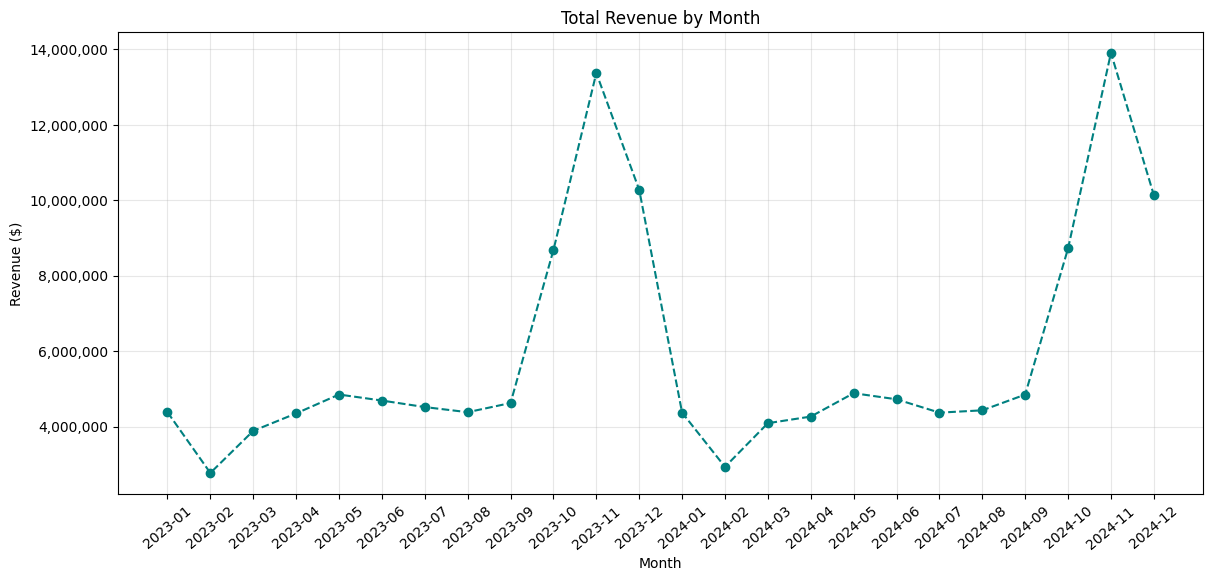

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(rpm.index.astype(str) , rpm.values , marker = "o" , color = "teal" , linestyle = "--")

plt.xticks(rotation = 40)

plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.title("Total Revenue by Month")
plt.grid(alpha=0.3)

import matplotlib.ticker as ticker

# Create the formatter rule
my_formatter = ticker.FuncFormatter(lambda y, _: f'{y:,.0f}')

# Apply it to BOTH major and minor ticks!
plt.gca().yaxis.set_major_formatter(my_formatter)
plt.gca().yaxis.set_minor_formatter(my_formatter)

plt.savefig("monthly_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

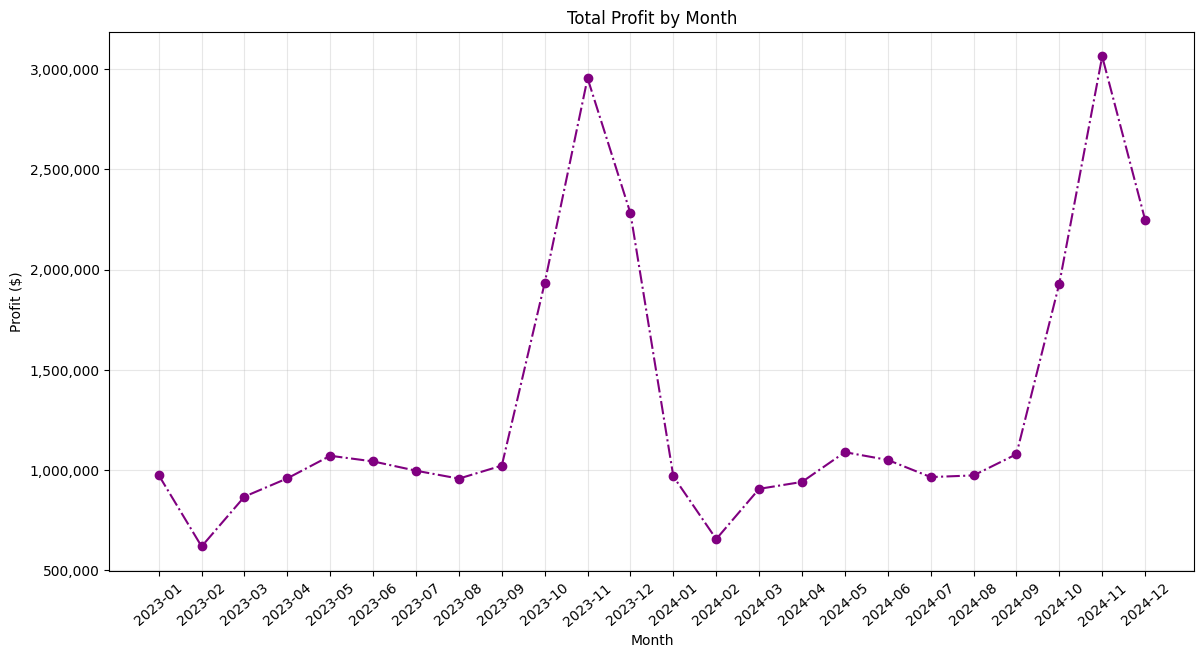

In [61]:
plt.figure(figsize=(14,7))

plt.plot(ppm.index.astype(str) , ppm.values , marker = "o" , color = "purple" , linestyle = "-.")

plt.xticks(rotation = 40)

plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.title("Total Profit by Month")
plt.grid(alpha=0.3)

import matplotlib.ticker as ticker

# Create the formatter rule
my_formatter = ticker.FuncFormatter(lambda y, _: f'{y:,.0f}')

# Apply it to BOTH major and minor ticks!
plt.gca().yaxis.set_major_formatter(my_formatter)
plt.gca().yaxis.set_minor_formatter(my_formatter)

plt.savefig("monthly_profit.png", dpi=300, bbox_inches="tight")

plt.show()

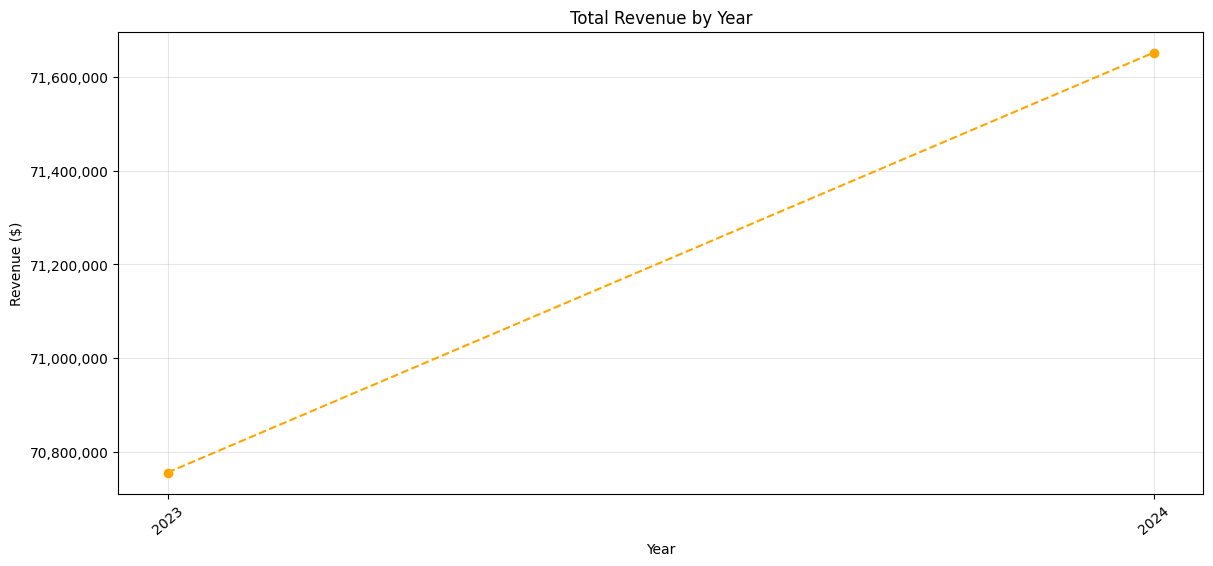

In [60]:
plt.figure(figsize=(14,6))

plt.plot(rpy.index.astype(str) , rpy.values , marker = "o" , color = "orange" , linestyle = "--")

plt.xticks(rotation = 40)

plt.xlabel("Year")
plt.ylabel("Revenue ($)")
plt.title("Total Revenue by Year")
plt.grid(alpha=0.3)

import matplotlib.ticker as ticker

# Create the formatter rule
my_formatter = ticker.FuncFormatter(lambda y, _: f'{y:,.0f}')

# Apply it to BOTH major and minor ticks!
plt.gca().yaxis.set_major_formatter(my_formatter)
plt.gca().yaxis.set_minor_formatter(my_formatter)

plt.savefig("yearly_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

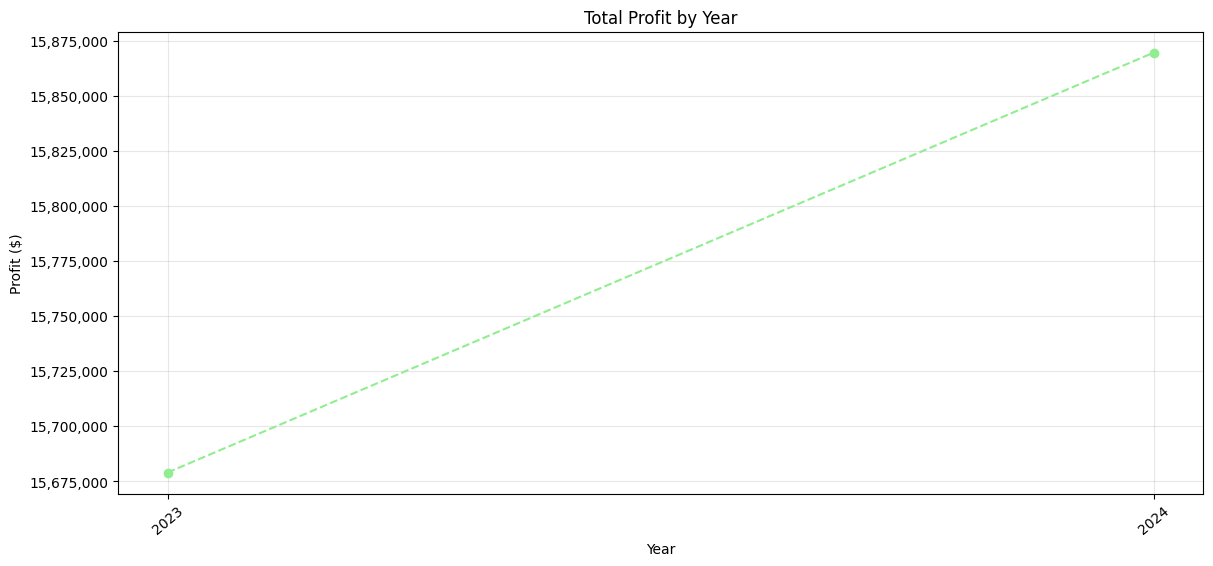

In [59]:
plt.figure(figsize=(14,6))

plt.plot(ppy.index.astype(str) , ppy.values , marker = "o" , color = "lightgreen" , linestyle = "--")

plt.xticks(rotation = 40)

plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.title("Total Profit by Year")
plt.grid(alpha=0.3)

import matplotlib.ticker as ticker

# Create the formatter rule
my_formatter = ticker.FuncFormatter(lambda y, _: f'{y:,.0f}')

# Apply it to BOTH major and minor ticks!
plt.gca().yaxis.set_major_formatter(my_formatter)
plt.gca().yaxis.set_minor_formatter(my_formatter)

plt.savefig("yearly_profit.png", dpi=300, bbox_inches="tight")

plt.show()

# Ques.16 Which product categories are our 'Cash Cows' (high revenue) versus our 'Hidden Gems' (high profit margin) ?

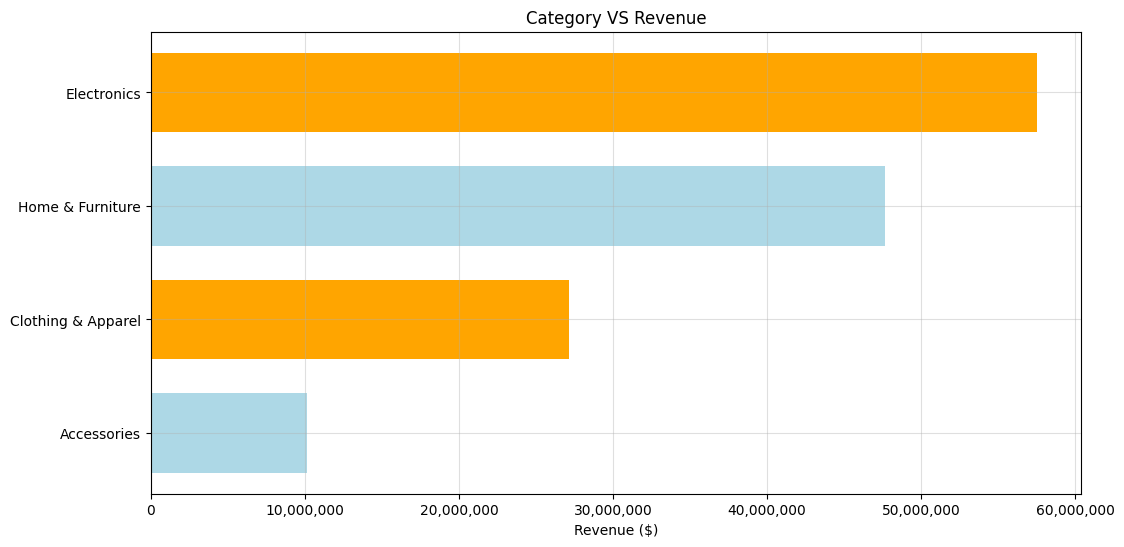

In [58]:
plt.figure(figsize = (12,6))

cash_cows = df.groupby("Category")["Revenue"].sum().sort_values(ascending=True).head()

plt.barh(cash_cows.index , cash_cows.values , color = ["lightblue","orange"] , height = 0.7)

plt.grid(alpha = 0.4)

plt.xlabel("Revenue ($)")
plt.title("Category VS Revenue")

# Format the x-axis to show clean dollar amounts (using the trick you just learned!)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.savefig("category_vs_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

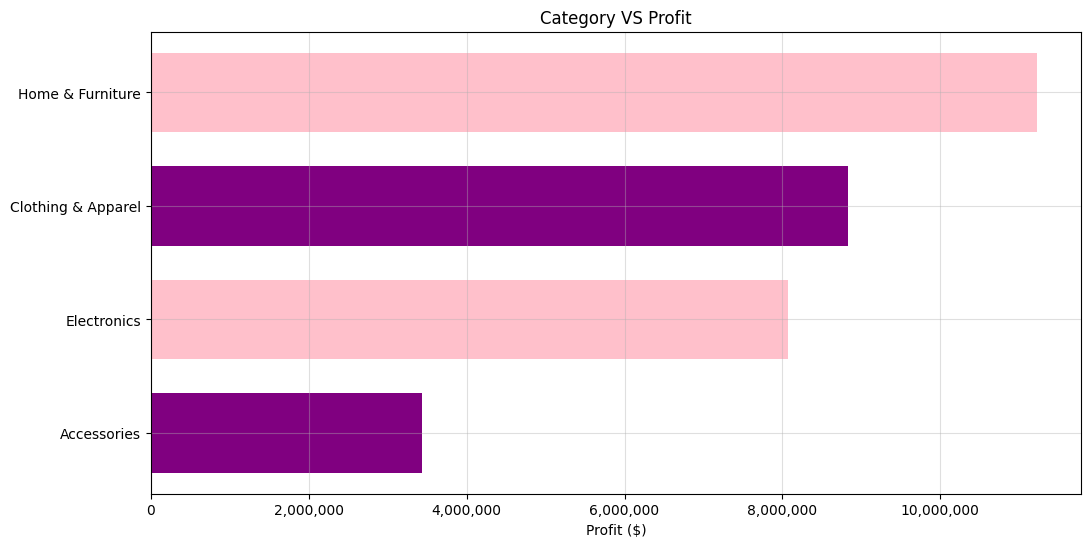

In [57]:
plt.figure(figsize = (12,6))

hidden_gems = df.groupby("Category")["Profit"].sum().sort_values(ascending=True).head()

plt.barh(hidden_gems.index , hidden_gems.values , color = ["purple","pink"] , height = 0.7)

plt.grid(alpha = 0.4)

plt.xlabel("Profit ($)")
plt.title("Category VS Profit")

# Format the x-axis to show clean dollar amounts (using the trick you just learned!)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.savefig("category_vs_profit.png", dpi=300, bbox_inches="tight")

plt.show()

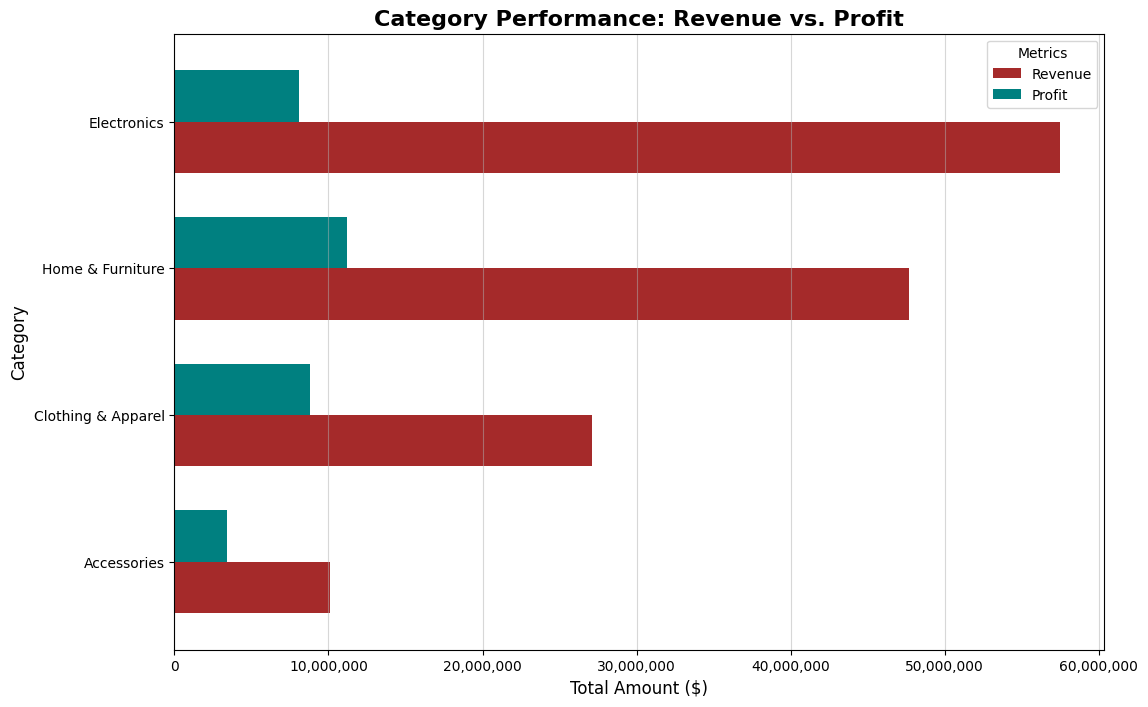

In [56]:
cat_stats = df.groupby("Category")[["Revenue", "Profit"]].sum().sort_values(by="Revenue", ascending=True)

# Use the Pandas shortcut to automatically group the bars
# We pass the colors as a list!
ax = cat_stats.plot( kind="barh", figsize=(12, 8), color=["brown", "teal"], width=0.7 )

# Format the chart (Matplotlib commands still work perfectly here!)
plt.title("Category Performance: Revenue vs. Profit", fontsize=16, fontweight="bold")
plt.xlabel("Total Amount ($)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.grid(alpha=0.5, axis="x") # Only grid the x-axis for cleaner look

# Format the x-axis to show clean dollar amounts (using the trick you just learned!)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.legend(title="Metrics")

plt.savefig("category_performance.png", dpi=300, bbox_inches="tight")

plt.show()

# Ques.17 Does selling more expensive items guarantee higher profit margins? 

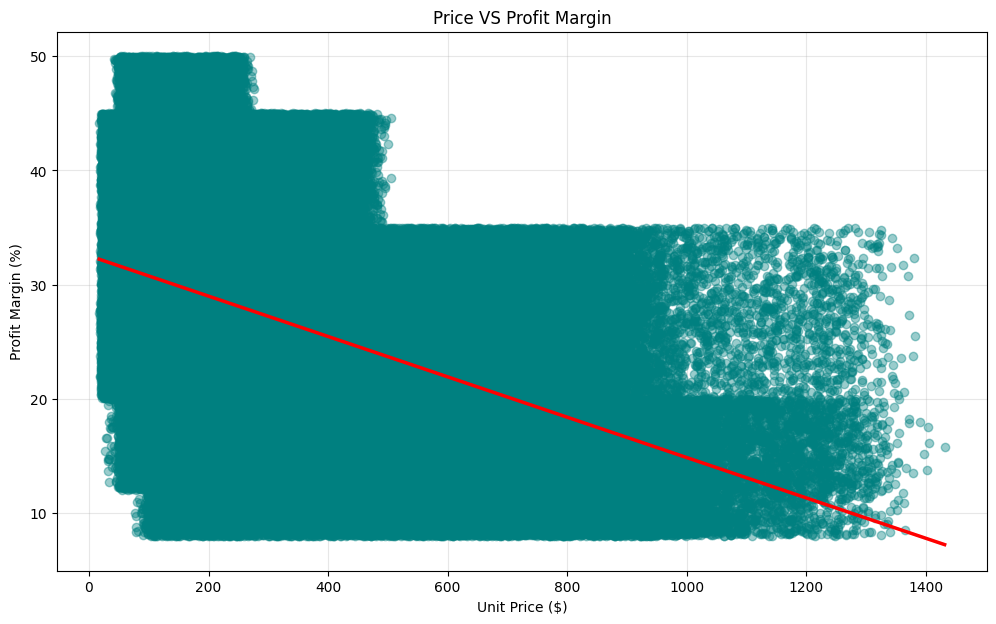

In [55]:
import seaborn as sns

# Feature Engineering: Create the Profit Margin column
df["Profit_Margin_%"] = (df["Profit"] / df["Revenue"]) * 100

plt.figure(figsize=(12, 7))

# Create the Scatter Plot with Regression Line
sns.regplot(
    data=df, 
    x="Unit_Price", 
    y="Profit_Margin_%", 
    scatter_kws={"alpha": 0.4, "color": "teal"}, 
    line_kws={"color": "red", "linewidth": 2.5}
)

plt.title("Price VS Profit Margin")
plt.xlabel("Unit Price ($)")
plt.ylabel("Profit Margin (%)")

plt.grid(alpha=0.3)
plt.gca().set_axisbelow(True) 

plt.savefig("price_vs_margin.png", dpi=300, bbox_inches="tight")

plt.show()

## No, selling more expensive items does not guarantee higher profit margins.

## As an item gets more expensive, the company makes a smaller percentage of profit

# Ques.18 What is the typical distribution of our transaction sizes, and do we have extreme outliers? 

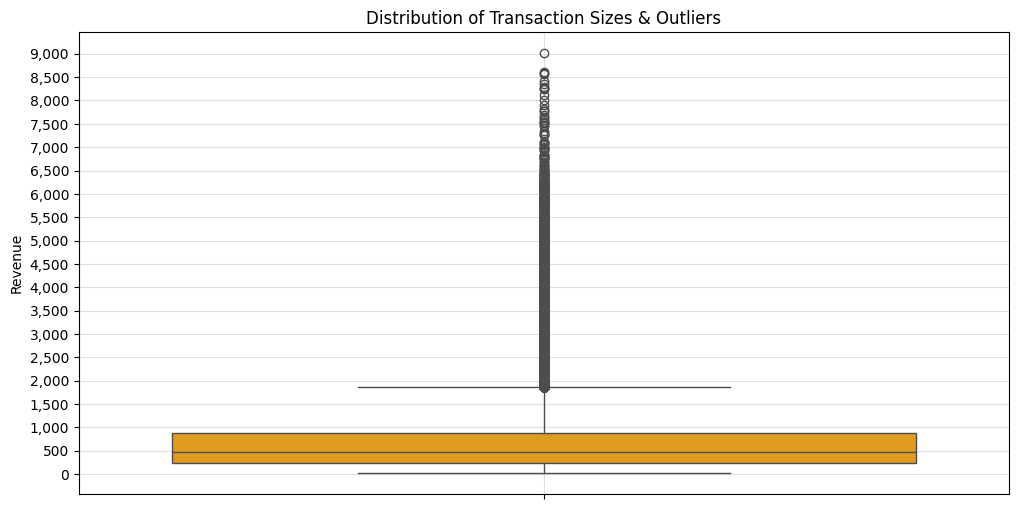

In [54]:
import seaborn as sns

plt.figure(figsize = (12,6))

sns.boxplot(data = df, y = "Revenue", color = "orange")

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(500))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.grid(alpha = 0.4)
plt.title("Distribution of Transaction Sizes & Outliers")

plt.savefig("transaction_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()


## The boxplot depicts that mostly the transaction sizes are concentrated in ~$(250 to 1000) range.

## Two completely different types of shoppers are depicted -

* __The Regular Shoppers__: Most people who walk through the door spend about $500. You get a lot of these shoppers every single day. They are reliable and keep the lights on.

* __The VIP Shoppers (The Outliers)__: A "big spender" walks in and drops up to $9,000 in a single visit.

In [63]:
df.to_csv("clean_sales_data.csv", index = False)